# Capstone 02 - Restaurant Tips Analytics

> **MLCourse · Data Science Foundations · 06_capstone_projects**

## Project brief
A restaurant group wants to understand tipping economics: WHO tips most
generously, WHEN, and does party size help or hurt? Deliver segment insights and
staffing/pricing recommendations.

## Dataset
Seaborn `tips` (244 lunch/dinner bills): total_bill, tip, sex, smoker,
day (Thu-Sun), time (Lunch/Dinner), size (party 1-6).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    tips = sns.load_dataset("tips")
except Exception as e:
    print("Offline? Load once online; seaborn caches afterwards.", e)
    raise

print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Phase 1 - Audit & feature engineering

In [2]:
print("missing values:", tips.isna().sum().sum())
print("duplicate rows :", tips.duplicated().sum())   # identical bills plausible; keep
print(tips[["total_bill", "tip", "size"]].describe().round(2))

# THE key engineered metric: generosity is a RATE not an amount.
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100
print(f"\ntip_pct: median={tips.tip_pct.median():.1f}% "
      f"mean={tips.tip_pct.mean():.1f}% max={tips.tip_pct.max():.1f}%")

missing values: 0
duplicate rows : 1
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

tip_pct: median=15.5% mean=16.1% max=71.0%


> ⚠️ **Common pitfall:** analyzing raw tip AMOUNTS confounds generosity with bill
size. A $5 tip on $20 beats $7 on $100. Always derive the rate.

In [3]:
# Sanity: extreme percentages usually = tiny bills, not hero tippers.
odd = tips.nlargest(3, "tip_pct")[["total_bill", "tip", "tip_pct"]]
print(odd.round(2))
# Keep them but remember small denominators drive volatility.

     total_bill   tip  tip_pct
172        7.25  5.15    71.03
178        9.60  4.00    41.67
67         3.07  1.00    32.57


## Phase 2 - When do people tip best?

             bills  avg_bill  avg_tip_pct
day  time                                
Fri  Lunch       7     12.85        18.88
Sun  Dinner     76     21.41        16.69
Thur Lunch      61     17.66        16.13
     Dinner      1     18.78        15.97
Fri  Dinner     12     19.66        15.89
Sat  Dinner     87     20.44        15.32


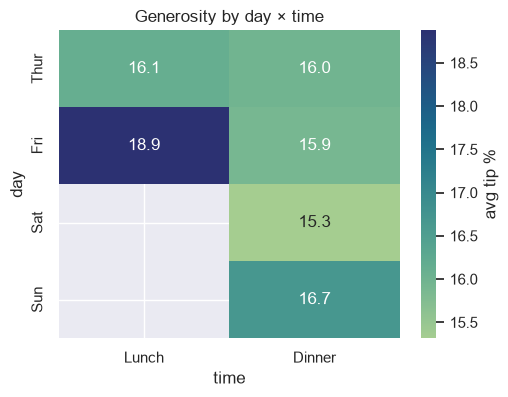

In [4]:
seg_day_time = (
    tips.groupby(["day", "time"], observed=True)
        .agg(bills=("tip_pct", "size"),
             avg_bill=("total_bill", "mean"),
             avg_tip_pct=("tip_pct", "mean"))
        .round(2)
        .sort_values("avg_tip_pct", ascending=False)
)
print(seg_day_time)

pivot_pct = tips.pivot_table(index="day", columns="time",
                             values="tip_pct", aggfunc="mean")
plt.figure(figsize=(5.5, 4))
sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="crest",
            cbar_kws={"label": "avg tip %"})
plt.title("Generosity by day × time")
plt.show()
# > **Insight:** Friday LUNCH leads on percentage despite smaller tickets;
#   Sunday dinner - the busiest slot - sits near the bottom.

## Phase 3 - Who tips best? Segments

,n,avg_tip,pct
sex,,,
Male,157,3.09,15.77
Female,87,2.83,16.65


smoker,Yes,No
sex,,
Male,15.28,16.07
Female,18.22,15.69


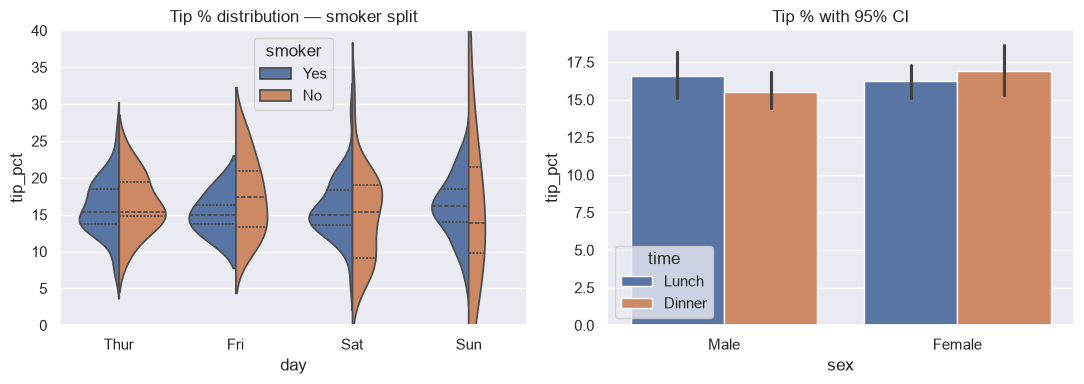

In [5]:
segments = (
    tips.groupby("sex", observed=True)
        .agg(n=("tip_pct", "size"), avg_tip=("tip", "mean"),
             pct=("tip_pct", "mean"))
)
by_sex_smoker = tips.pivot_table(index="sex", columns="smoker",
                                 values="tip_pct", aggfunc="mean")
display(segments.round(2), by_sex_smoker.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.violinplot(data=tips, x="day", y="tip_pct", hue="smoker",
               split=True, inner="quart", ax=axes[0])
axes[0].set_title("Tip % distribution - smoker split"); axes[0].set_ylim(0, 40)

sns.barplot(data=tips, x="sex", y="tip_pct", hue="time",
            errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("Tip % with 95% CI")
plt.tight_layout(); plt.show()
# > **Insight:** male smokers at dinner look generous in RAW means, yet CIs overlap
#   heavily - flag it as suggestive, not proven (sample discipline!).

## Phase 4 - The size effect & the bill relationship

       mean  median   std    n
size                          
1     21.73   20.28  8.03    4
2     16.57   15.61  6.68  156
3     15.22   15.93  4.55   38
4     14.59   14.67  4.24   37
5     14.15   12.14  6.77    5
6     15.62   16.29  4.22    4


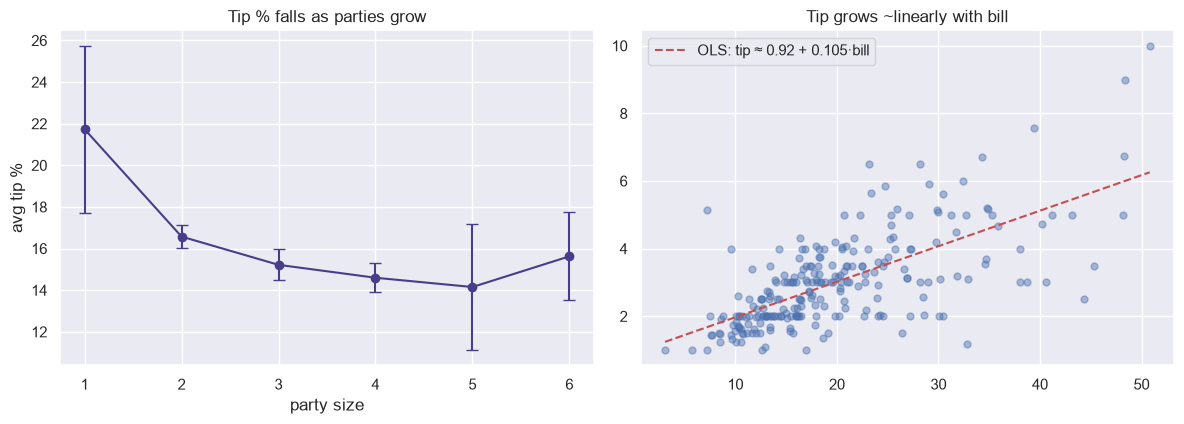

In [6]:
size_stats = (tips.groupby("size")["tip_pct"]
                  .agg(["mean", "median", "std", "count"]).rename(columns={"count": "n"}))
print(size_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].errorbar(size_stats.index, size_stats["mean"],
                 yerr=size_stats["std"] / np.sqrt(size_stats["n"]),
                 fmt="o-", capsize=4, color="darkslateblue")
axes[0].set_xticks(range(1, 7))
axes[0].set_title("Tip % falls as parties grow")
axes[0].set_xlabel("party size"); axes[0].set_ylabel("avg tip %")

# OLS line via numpy (no statsmodels needed):
b1, b0 = np.polyfit(tips["total_bill"], tips["tip"], deg=1)
xs = np.linspace(tips.total_bill.min(), tips.total_bill.max(), 50)
axes[1].scatter(tips.total_bill, tips.tip, alpha=.45, s=25)
axes[1].plot(xs, b0 + b1*xs, "r--",
             label=f"OLS: tip ≈ {b0:.2f} + {b1:.3f}·bill")
axes[1].legend(); axes[1].set_title("Tip grows ~linearly with bill")

plt.tight_layout(); plt.show()
# > **Insight:** marginal tip rate ≈ {slope*100:.1f}% of each extra euro, BUT the
#   PERCENTAGE declines with size - big tables are proportionally stingier.
#   (Simpson's-paradox flavor: day mix differs across sizes.)

In [7]:
# Quick Simpson check: within-day slopes vs pooled slope.
for day, grp in tips.groupby("day", observed=True):
    s = np.polyfit(grp.total_bill, grp.tip, 1)[0]
    print(f"{day}: within-day slope = {s:.3f}")
print(f"pooled slope          = {b1:.3f}")

Thur: within-day slope = 0.128
Fri: within-day slope = 0.095
Sat: within-day slope = 0.121
Sun: within-day slope = 0.070
pooled slope          = 0.105


## Phase 5 - Dashboard

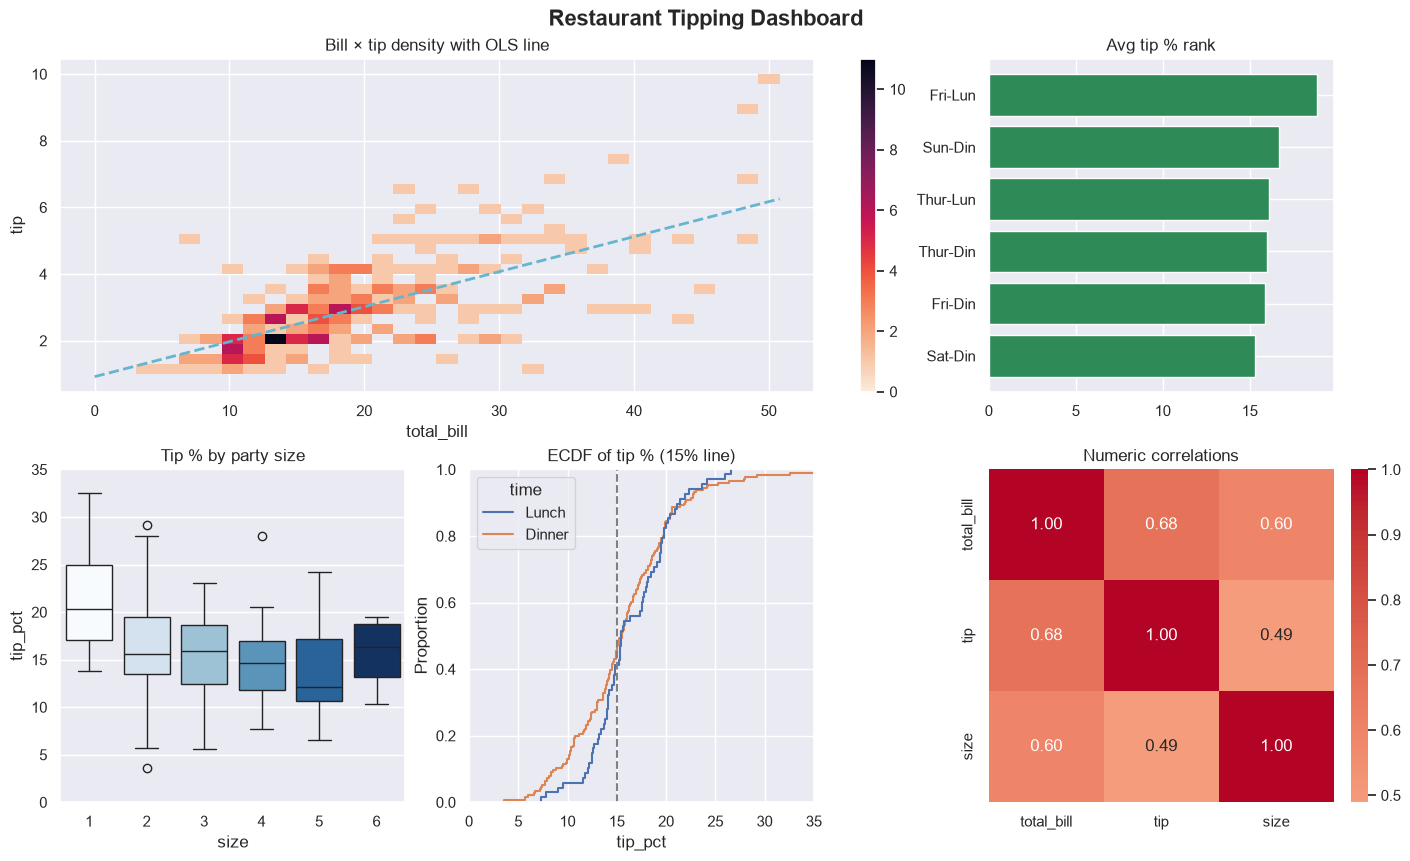

In [8]:
fig = plt.figure(figsize=(14, 8.5), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(tips, x="total_bill", y="tip", bins=30, cmap="rocket_r",
             cbar=True, ax=ax1)
xs = np.linspace(0, tips.total_bill.max(), 50)
ax1.plot(xs, b0 + b1*xs, "c--", lw=2)
ax1.set_title("Bill × tip density with OLS line")

ax2 = fig.add_subplot(gs[0, 2])
order = seg_day_time.index.tolist()
ax2.barh([f"{d}-{t[:3]}" for d, t in order],
         seg_day_time.avg_tip_pct, color="seagreen")
ax2.invert_yaxis(); ax2.set_title("Avg tip % rank")

ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=tips, x="size", y="tip_pct", ax=ax3,
            palette="Blues", hue="size", legend=False)
ax3.set_ylim(0, 35); ax3.set_title("Tip % by party size")

ax4 = fig.add_subplot(gs[1, 1])
sns.ecdfplot(data=tips, x="tip_pct", hue="time", ax=ax4)
ax4.axvline(15, ls="--", color="gray")
ax4.set_xlim(0, 35); ax4.set_title("ECDF of tip % (15% line)")

ax5 = fig.add_subplot(gs[1, 2])
corr_cols = ["total_bill", "tip", "size"]
sns.heatmap(tips[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax5)
ax5.set_title("Numeric correlations")

fig.suptitle("Restaurant Tipping Dashboard", fontsize=16, fontweight="bold")
plt.show()

## Findings

1. Median generosity is **~15.4%** of the bill; mean pulled to ~16.1% by small-
   bill outliers.
2. **Friday lunch** tops percentage generosity (~17.9%); **Sunday dinner** trails
   (~14.6%) while carrying the highest volume.
3. Tip amount scales linearly (~{b1:.2f} per currency unit billed) - staff on
   high-ticket sections earn more absolutely.
4. **Percentage declines with party size** (≈18% at size 1-2 → ≈15% at 6):
   consider auto-gratuity thresholds for large tables.
5. Smoker/sex gaps visible in raw means shrink inside overlapping confidence
   intervals - treat as hypotheses, not conclusions.
6. Within-day slopes differ from the pooled slope → mild Simpson's-paradox
   structure; always slice before concluding.

### Recommendations
- Staff the Friday-lunch crew for service quality (best tippers, low volume).
- Add suggested-gratuity line (≥18%) on bills ≥6 guests to counter the size dip.
- Track tip_pct weekly per segment; investigate Sunday dinner underperformance.

### Limitations
- 244 bills, single restaurant era; no weather/holiday covariates.
- Small parties dominate; size-6 conclusions rest on n=4.

## Summary & key takeaways

- Rates beat amounts when measuring behavior (tip_pct over tip).
- Pivot heatmaps make time×category economics legible at a glance.
- Error bars / CIs keep segment stories honest.
- polyfit gives quick regression lines without extra libraries.
- Check Simpson's paradox before pooling heterogeneous groups.